In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv("C:/Users/priyanka das/Downloads/housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
df.tail(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


In [4]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [5]:
from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings("ignore")

In [6]:
df.shape

(20640, 10)

In [8]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [11]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())

In [12]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [13]:
print(df.shape)

(20640, 10)


In [15]:
df.dtypes

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

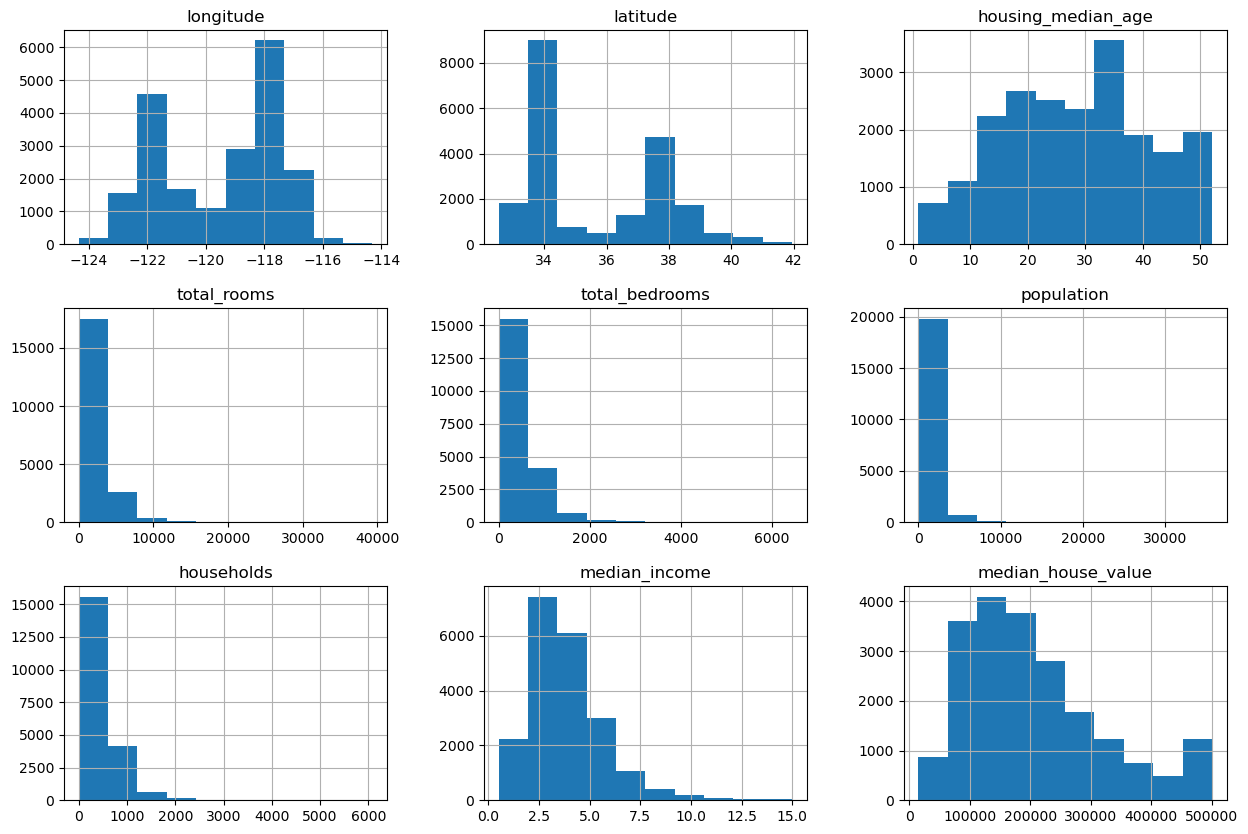

In [18]:
df.hist(figsize=(15,10))
plt.show()

In [19]:
numeric_df = df.select_dtypes(include=np.number)

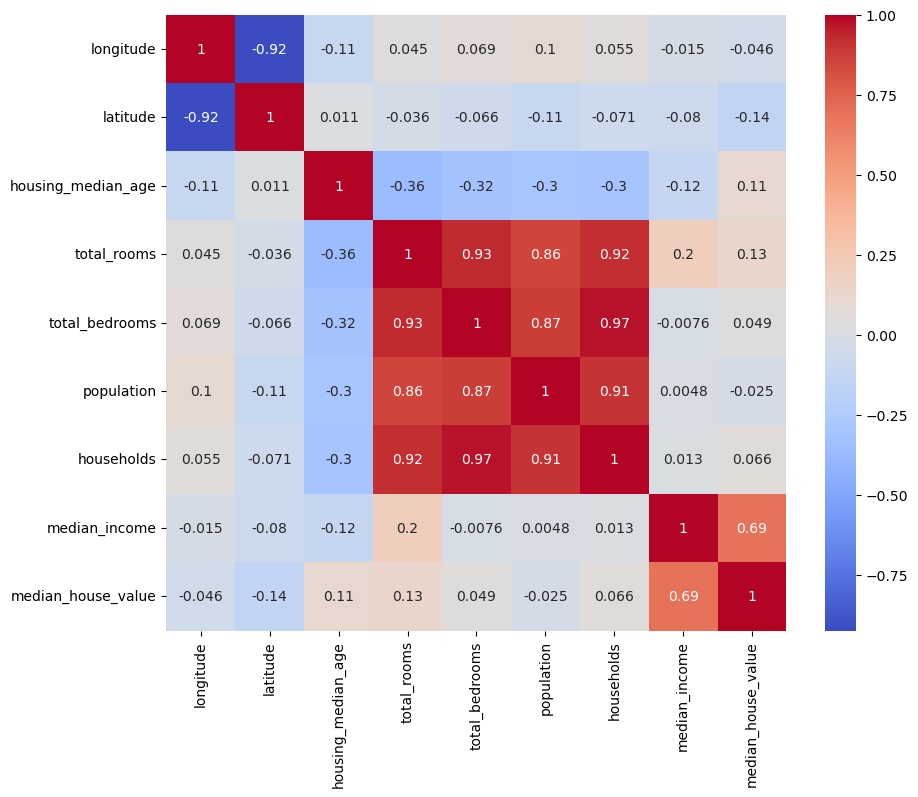

In [22]:
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(),annot=True,cmap="coolwarm")
plt.show()

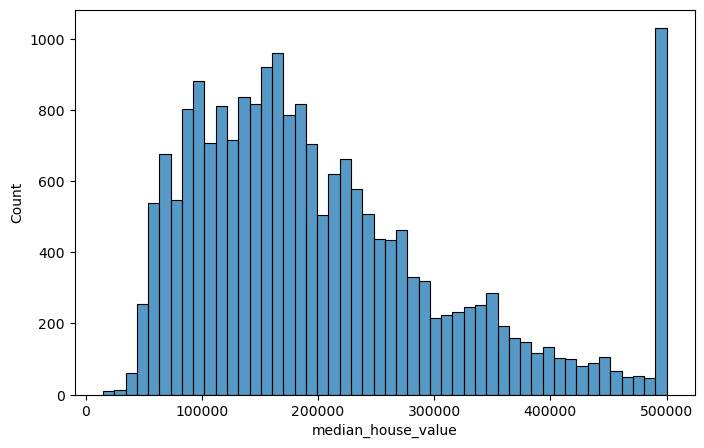

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df["median_house_value"],bins=50)
plt.show()

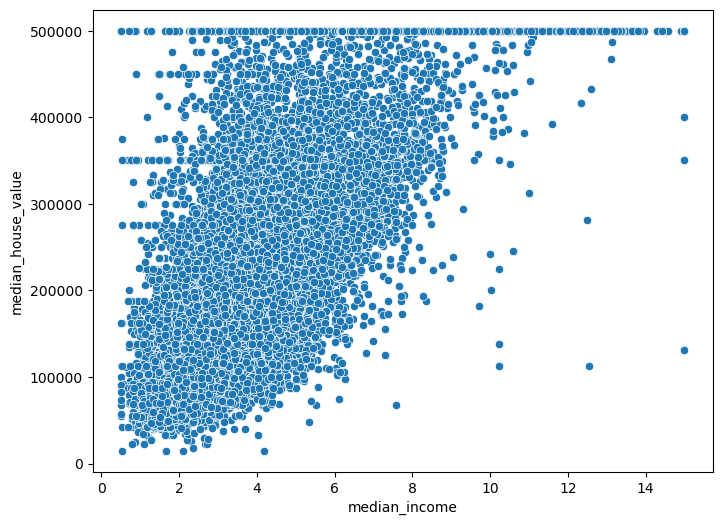

In [24]:
plt.figure(figsize=(8,6))
sns.scatterplot(
x=df["median_income"],
y=df["median_house_value"]
)
plt.show()

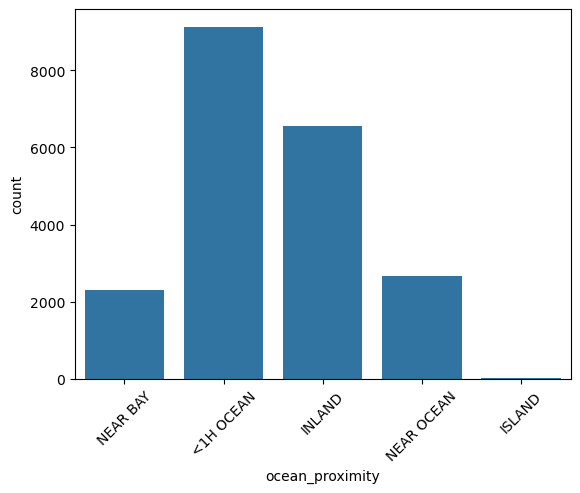

In [25]:
sns.countplot(
x=df["ocean_proximity"]
)

plt.xticks(rotation=45)

plt.show()

In [26]:
X = df.drop("median_house_value",axis=1)

y = df["median_house_value"]

In [27]:
numeric_features = X.select_dtypes(include=np.number).columns

categorical_features = X.select_dtypes(include="object").columns

In [28]:
numeric_transformer = Pipeline([
("scaler",StandardScaler())
])

categorical_transformer = Pipeline([
("encoder",OneHotEncoder(handle_unknown="ignore"))
])

In [29]:
preprocessor = ColumnTransformer(
[
("num",numeric_transformer,numeric_features),

("cat",categorical_transformer,categorical_features)
]
)

In [30]:
X_train,X_test,y_train,y_test=train_test_split(

X,
y,
test_size=0.2,
random_state=42

)

In [31]:
model = Pipeline([
("preprocessor",preprocessor),

("regressor",RandomForestRegressor(
n_estimators=200,
random_state=42
))
])

In [32]:
model.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [35]:
pred=model.predict(X_test)

In [36]:
mae=mean_absolute_error(y_test,pred)

print(mae)

31464.93347383721


In [37]:
rmse=np.sqrt(mean_squared_error(y_test,pred))

print(rmse)

48781.55875664814


In [38]:
r2=r2_score(y_test,pred)

print(r2)

0.818404748880555


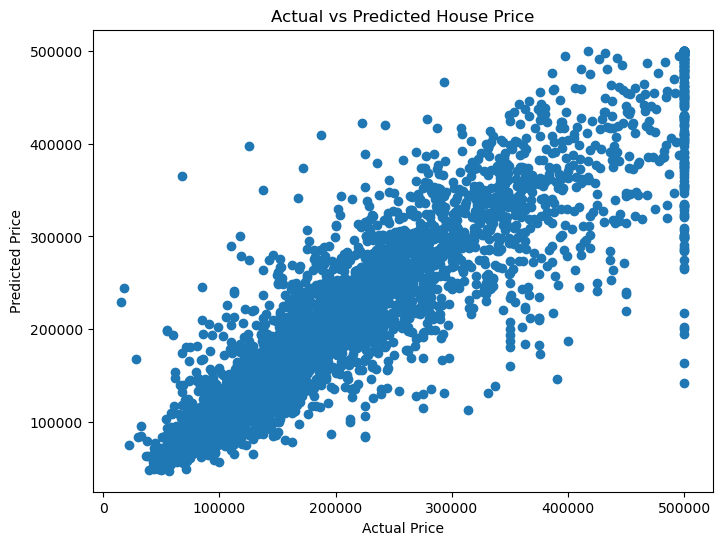

In [39]:
plt.figure(figsize=(8,6))

plt.scatter(y_test,pred)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Price")

plt.show()

In [40]:
import joblib

joblib.dump(model,"house_price_model.pkl")

['house_price_model.pkl']

In [41]:
sample=pd.DataFrame({

"longitude":[-122],

"latitude":[37],

"housing_median_age":[25],

"total_rooms":[1500],

"total_bedrooms":[300],

"population":[900],

"households":[280],

"median_income":[5],

"ocean_proximity":["NEAR BAY"]

})

In [42]:
model.predict(sample)

array([304752.545])

In [43]:
import joblib

joblib.dump(model, "house_price_model.pkl")

['house_price_model.pkl']

In [44]:
import joblib

model = joblib.load("house_price_model.pkl")

In [45]:
import joblib

model = joblib.load(r"C:\Users\priyanka das\house_price_model.pkl")

In [46]:
import os
print(os.getcwd())

C:\Users\priyanka das


In [47]:
import joblib

model = joblib.load("house_price_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!
